# **Alura Challenge TelecomX Parte 2**

## 🛠️ **Preparación de los Datos**

### **Extracción del Archivo Tratado**

In [1]:
import pandas as pd

In [2]:
url = "https://raw.githubusercontent.com/epjuarez/alura-challenge-telecomx2/refs/heads/main/datos_tratados.csv"

df = pd.read_csv(url)

df.head()

,customerid,churn,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_internetservice,...,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_contract,account_paperlessbilling,account_paymentmethod,account_charges_monthly,account_charges_total,cuentas_diarias
0,0002-orfbo,0,female,0,1,1,9,1,no,dsl,...,no,yes,yes,no,one year,1,mailed check,65.6,593.30,2.186667
1,0003-mknfe,0,male,0,0,0,9,1,yes,dsl,...,no,no,no,yes,month-to-month,0,mailed check,59.9,542.40,1.996667
2,0004-tlhlj,1,male,0,0,0,4,1,no,fiber optic,...,yes,no,no,no,month-to-month,1,electronic check,73.9,280.85,2.463333
3,0011-igkff,1,male,1,1,0,13,1,no,fiber optic,...,yes,no,yes,yes,month-to-month,1,electronic check,98.0,1237.85,3.266667
4,0013-exchz,1,female,1,1,0,3,1,no,fiber optic,...,no,yes,yes,no,month-to-month,1,mailed check,83.9,267.40,2.796667


In [3]:
df.info()
df.shape
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerid                 7043 non-null   object 
 1   churn                      7043 non-null   int64  
 2   customer_gender            7043 non-null   object 
 3   customer_seniorcitizen     7043 non-null   int64  
 4   customer_partner           7043 non-null   int64  
 5   customer_dependents        7043 non-null   int64  
 6   customer_tenure            7043 non-null   int64  
 7   phone_phoneservice         7043 non-null   int64  
 8   phone_multiplelines        7043 non-null   object 
 9   internet_internetservice   7043 non-null   object 
 10  internet_onlinesecurity    7043 non-null   object 
 11  internet_onlinebackup      7043 non-null   object 
 12  internet_deviceprotection  7043 non-null   object 
 13  internet_techsupport       7043 non-null   objec

Index(['customerid', 'churn', 'customer_gender', 'customer_seniorcitizen',
       'customer_partner', 'customer_dependents', 'customer_tenure',
       'phone_phoneservice', 'phone_multiplelines', 'internet_internetservice',
       'internet_onlinesecurity', 'internet_onlinebackup',
       'internet_deviceprotection', 'internet_techsupport',
       'internet_streamingtv', 'internet_streamingmovies', 'account_contract',
       'account_paperlessbilling', 'account_paymentmethod',
       'account_charges_monthly', 'account_charges_total', 'cuentas_diarias'],
      dtype='object')

### **Eliminación de Columnas Irrelevantes**

In [4]:
df = df.drop(columns=['customerid'])

In [5]:
df.columns

Index(['churn', 'customer_gender', 'customer_seniorcitizen',
       'customer_partner', 'customer_dependents', 'customer_tenure',
       'phone_phoneservice', 'phone_multiplelines', 'internet_internetservice',
       'internet_onlinesecurity', 'internet_onlinebackup',
       'internet_deviceprotection', 'internet_techsupport',
       'internet_streamingtv', 'internet_streamingmovies', 'account_contract',
       'account_paperlessbilling', 'account_paymentmethod',
       'account_charges_monthly', 'account_charges_total', 'cuentas_diarias'],
      dtype='object')

### **Encoding**

In [6]:
df.dtypes

,0
churn,int64
customer_gender,object
customer_seniorcitizen,int64
customer_partner,int64
customer_dependents,int64
customer_tenure,int64
phone_phoneservice,int64
phone_multiplelines,object
internet_internetservice,object
internet_onlinesecurity,object


In [7]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [8]:
df_encoded.head()

,churn,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,account_paperlessbilling,account_charges_monthly,account_charges_total,cuentas_diarias,...,internet_techsupport_yes,internet_streamingtv_no internet service,internet_streamingtv_yes,internet_streamingmovies_no internet service,internet_streamingmovies_yes,account_contract_one year,account_contract_two year,account_paymentmethod_credit card (automatic),account_paymentmethod_electronic check,account_paymentmethod_mailed check
0,0,0,1,1,9,1,1,65.6,593.30,2.186667,...,True,False,True,False,False,True,False,False,False,True
1,0,0,0,0,9,1,0,59.9,542.40,1.996667,...,False,False,False,False,True,False,False,False,False,True
2,1,0,0,0,4,1,1,73.9,280.85,2.463333,...,False,False,False,False,False,False,False,False,True,False
3,1,1,1,0,13,1,1,98.0,1237.85,3.266667,...,False,False,True,False,True,False,False,False,True,False
4,1,1,1,0,3,1,1,83.9,267.40,2.796667,...,True,False,True,False,False,False,False,False,False,True


In [9]:
df_encoded.dtypes.value_counts()

,count
bool,22
int64,7
float64,3


### **Verificación de la Proporción de Cancelación (Churn)**

In [10]:
churn_count = df_encoded['churn'].value_counts()

churn_ratio = df_encoded['churn'].value_counts(normalize=True) * 100

print("Conteo de clientes por clase:")
print(churn_count)

print("\nProporción (%):")
print(churn_ratio)

Conteo de clientes por clase:
churn
0    5174
1    1869
Name: count, dtype: int64

Proporción (%):
churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


### Balanceo de Clases (opcional)

In [13]:
X = df_encoded.drop('churn', axis=1)
y = df_encoded['churn']

### **Normalización o Estandarización (si es necesario)**

In [12]:
from sklearn.model_selection import train_test_split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [16]:
from sklearn.preprocessing import StandardScaler

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## **🎯 Correlación y Selección de Variables**

### **Análisis de Correlación**

In [18]:
corr_matrix = df_encoded.corr()

corr_matrix.head()

,churn,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,account_paperlessbilling,account_charges_monthly,account_charges_total,cuentas_diarias,...,internet_techsupport_yes,internet_streamingtv_no internet service,internet_streamingtv_yes,internet_streamingmovies_no internet service,internet_streamingmovies_yes,account_contract_one year,account_contract_two year,account_paymentmethod_credit card (automatic),account_paymentmethod_electronic check,account_paymentmethod_mailed check
churn,1.000000,0.150889,-0.150448,-0.164221,-0.352229,0.011942,0.191825,0.193356,-0.198324,0.193356,...,-0.164674,-0.227890,0.063228,-0.227890,0.061382,-0.177820,-0.302253,-0.134302,0.301919,-0.091683
customer_seniorcitizen,0.150889,1.000000,0.016479,-0.211185,0.016567,0.008576,0.156530,0.220173,0.103006,0.220173,...,-0.060625,-0.182742,0.105378,-0.182742,0.120176,-0.046262,-0.117000,-0.024135,0.171718,-0.153477
customer_partner,-0.150448,0.016479,1.000000,0.452676,0.379697,0.017706,-0.014877,0.096848,0.317504,0.096848,...,0.119999,0.000615,0.124666,0.000615,0.117412,0.082783,0.248091,0.082029,-0.083852,-0.095125
customer_dependents,-0.164221,-0.211185,0.452676,1.000000,0.159712,-0.001762,-0.111377,-0.113890,0.062078,-0.113890,...,0.063268,0.139812,-0.016558,0.139812,-0.039741,0.068368,0.204613,0.060267,-0.150642,0.059071
customer_tenure,-0.352229,0.016567,0.379697,0.159712,1.000000,0.008448,0.006152,0.247900,0.826178,0.247900,...,0.324221,-0.039062,0.279756,-0.039062,0.286111,0.202570,0.558533,0.233006,-0.208363,-0.233852


In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

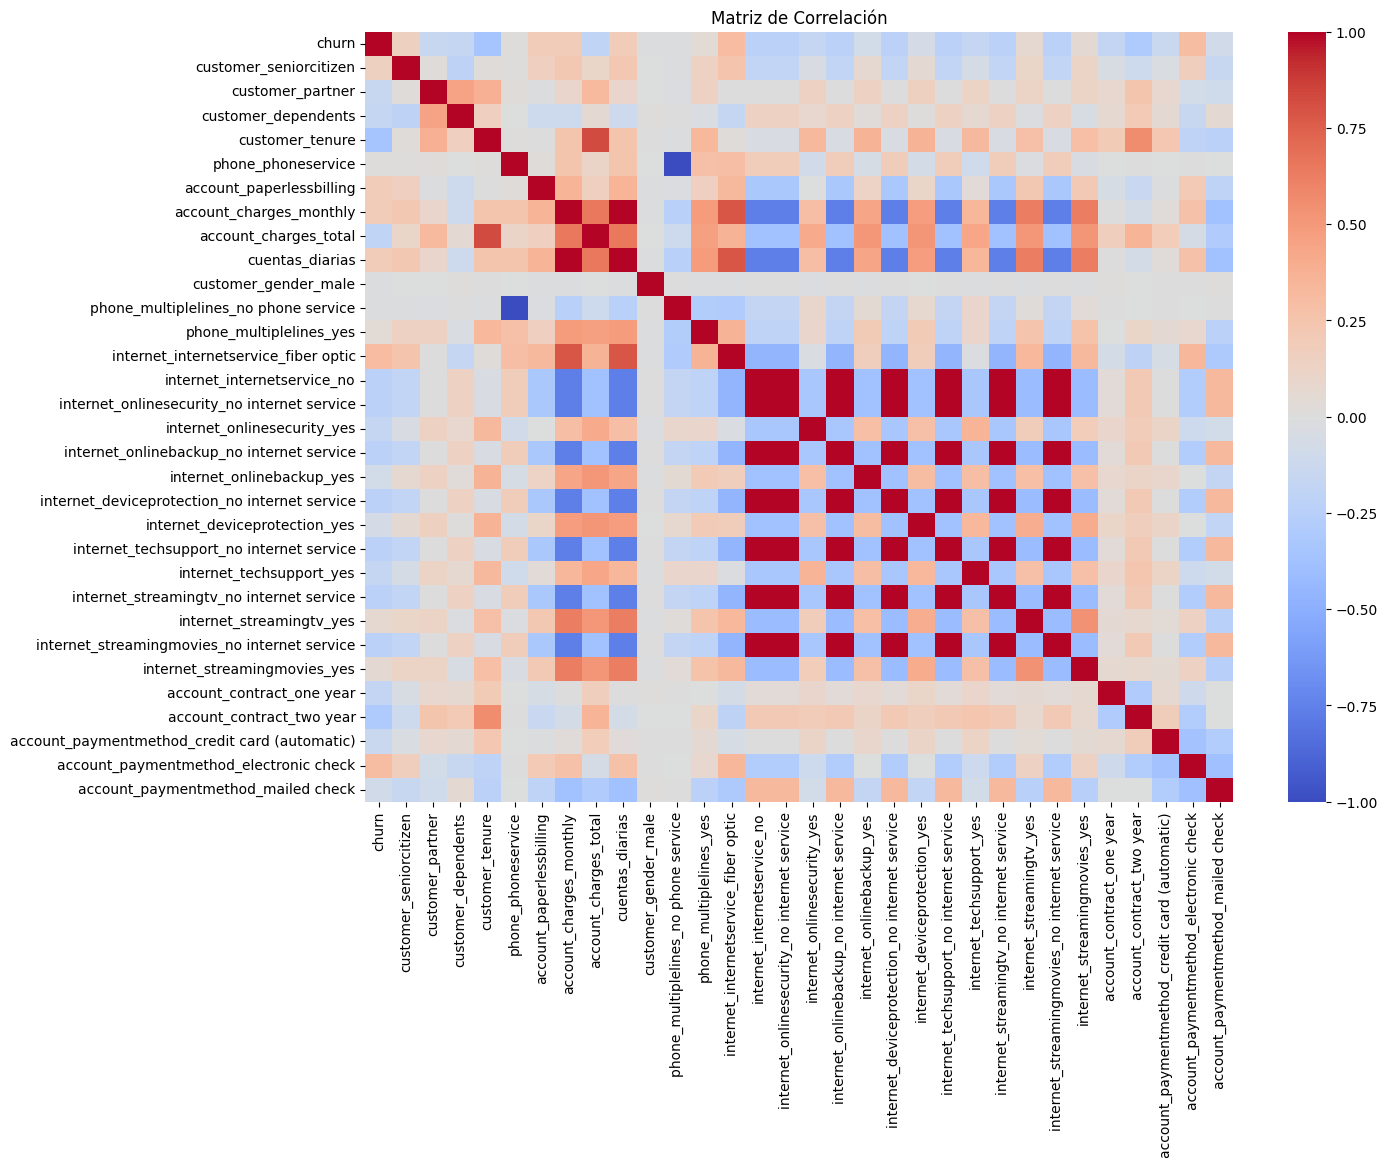

In [20]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df_encoded.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Matriz de Correlación")
plt.show()

In [21]:
corr_churn = df_encoded.corr()['churn'].sort_values(ascending=False)

corr_churn

,churn
churn,1.000000
internet_internetservice_fiber optic,0.308020
account_paymentmethod_electronic check,0.301919
account_charges_monthly,0.193356
cuentas_diarias,0.193356
account_paperlessbilling,0.191825
customer_seniorcitizen,0.150889
internet_streamingtv_yes,0.063228
internet_streamingmovies_yes,0.061382
phone_multiplelines_yes,0.040102


In [22]:
top_corr = corr_churn[abs(corr_churn) > 0.2]

top_corr

,churn
churn,1.000000
internet_internetservice_fiber optic,0.308020
account_paymentmethod_electronic check,0.301919
internet_internetservice_no,-0.227890
internet_streamingtv_no internet service,-0.227890
internet_onlinesecurity_no internet service,-0.227890
internet_onlinebackup_no internet service,-0.227890
internet_deviceprotection_no internet service,-0.227890
internet_streamingmovies_no internet service,-0.227890
internet_techsupport_no internet service,-0.227890


In [24]:
selected_features = top_corr.index

corr_selected = df_encoded[selected_features].corr()

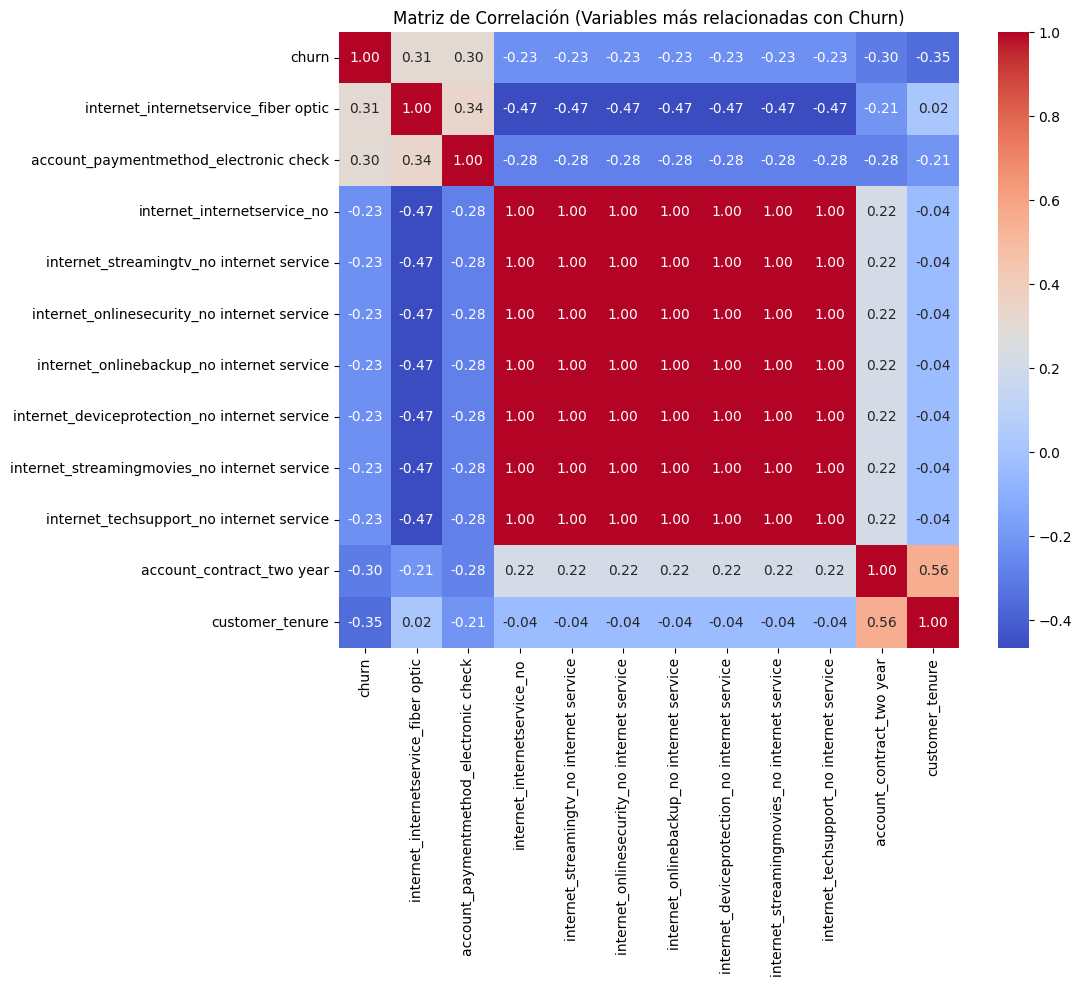

In [25]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_selected,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de Correlación (Variables más relacionadas con Churn)")
plt.show()

### **Análisis Dirigido**

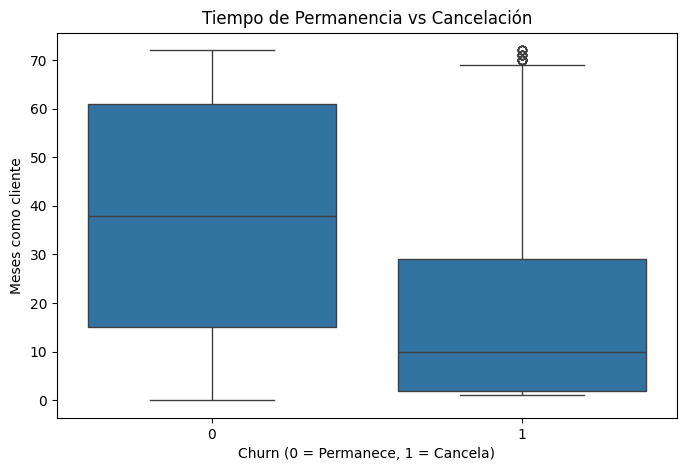

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(x='churn', y='customer_tenure', data=df_encoded)

plt.title('Tiempo de Permanencia vs Cancelación')
plt.xlabel('Churn (0 = Permanece, 1 = Cancela)')
plt.ylabel('Meses como cliente')

plt.show()

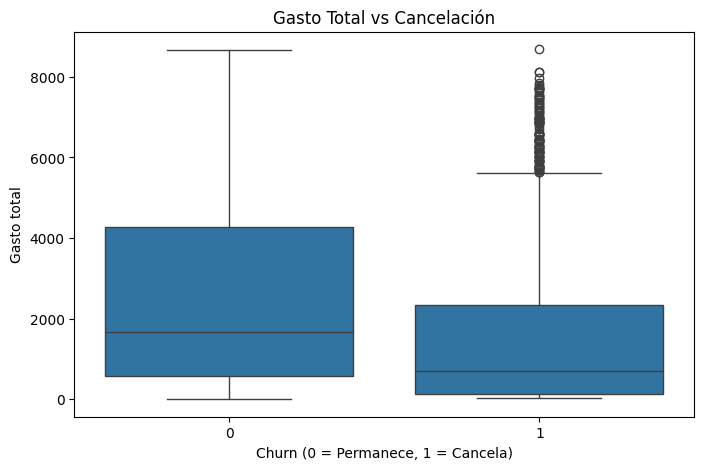

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(x='churn', y='account_charges_total', data=df_encoded)

plt.title('Gasto Total vs Cancelación')
plt.xlabel('Churn (0 = Permanece, 1 = Cancela)')
plt.ylabel('Gasto total')

plt.show()

## **🤖 Modelado Predictivo**

### **Separación de Datos**

In [29]:
X = df_encoded.drop('churn', axis=1)
y = df_encoded['churn']

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (5634, 31)
Datos de prueba: (1409, 31)


In [32]:
print("Proporción de churn en entrenamiento:")
print(y_train.value_counts(normalize=True))

print("\nProporción de churn en prueba:")
print(y_test.value_counts(normalize=True))

Proporción de churn en entrenamiento:
churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Proporción de churn en prueba:
churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64
